In [7]:
import pandas as pd
import plotly.express as px
import numpy as np

# Dataset: Airbnb London Listings

df = pd.read_csv('../data/airbnb_london.csv')

print(f"Loaded: {len(df)} listings")
print(df.describe().round(1))

Loaded: 2500 listings
        price  minimum_nights  number_of_reviews  availability_365  \
count  2500.0          2500.0             2500.0            2500.0   
mean    148.6            14.8              147.9             183.7   
std     110.9             8.4               86.3             105.5   
min      20.5             1.0                0.0               0.0   
25%      71.7             8.0               74.0              92.0   
50%     117.5            15.0              145.0             182.0   
75%     188.9            22.0              222.2             277.0   
max    1032.4            29.0              299.0             364.0   

       reviews_per_month  
count             2500.0  
mean                 2.0  
std                  2.0  
min                  0.0  
25%                  0.6  
50%                  1.4  
75%                  2.8  
max                 15.2  


In [6]:
p95 = df['price'].quantile(0.95)
df_cap = df[df['price'] <= p95]
print(f"95th percentile price: £{p95:.0f}")
print(df_cap.groupby('room_type')['price'].describe().round(1))

95th percentile price: £373
                  count   mean   std   min    25%    50%    75%    max
room_type                                                             
Entire home/apt  1251.0  176.3  75.7  28.0  119.6  163.4  223.5  372.6
Private room      942.0   87.3  39.5  20.9   59.0   78.6  106.0  277.9
Shared room       182.0   46.3  14.1  20.5   36.8   44.1   54.3   92.8


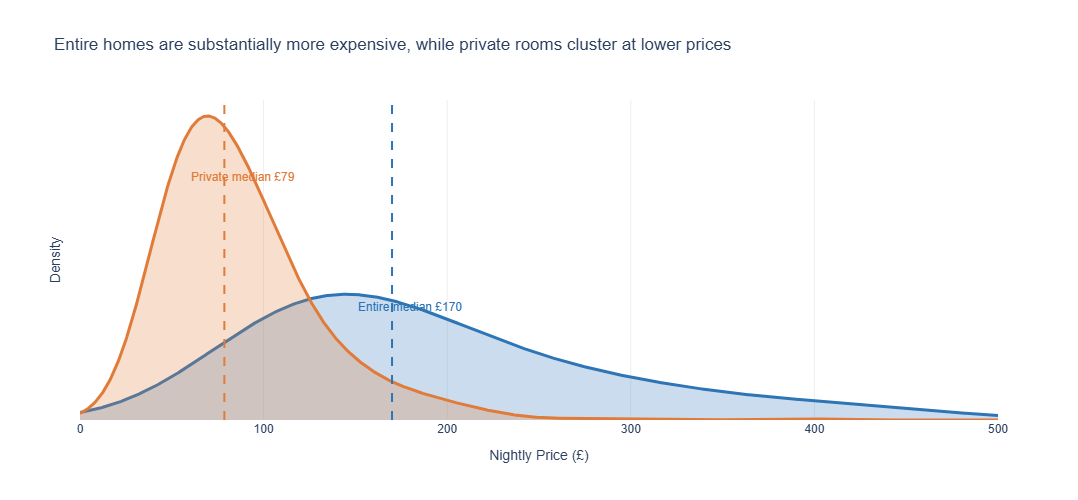

In [10]:
df_two = df[df['room_type'].isin(['Entire home/apt', 'Private room'])]

df_two = df_two[df_two['price'] < 500]

# ── Split prices ──────────────────────────────────────────────────────────────
entire = df_two[df_two['room_type'] == 'Entire home/apt']['price']
private = df_two[df_two['room_type'] == 'Private room']['price']

# Median prices
med_entire = entire.median()
med_private = private.median()

# ── KDE calculation ───────────────────────────────────────────────────────────
x = np.linspace(0, 500, 1000)

kde_entire = gaussian_kde(entire, bw_method=0.4)
kde_private = gaussian_kde(private, bw_method=0.4)

y_entire = kde_entire(x)
y_private = kde_private(x)

# ── Build chart ───────────────────────────────────────────────────────────────
fig = go.Figure()

# Entire homes
fig.add_trace(
    go.Scatter(
        x=x,
        y=y_entire,
        mode='lines',
        line=dict(color='#2E75B6', width=3),
        fill='tozeroy',
        fillcolor='rgba(46,117,182,0.25)',
        name='Entire home/apt'
    )
)

# Private rooms
fig.add_trace(
    go.Scatter(
        x=x,
        y=y_private,
        mode='lines',
        line=dict(color='#E07B39', width=3),
        fill='tozeroy',
        fillcolor='rgba(224,123,57,0.25)',
        name='Private room'
    )
)

# ── Median lines ──────────────────────────────────────────────────────────────
fig.add_vline(
    x=med_entire,
    line_dash='dash',
    line_color='#2E75B6'
)

fig.add_vline(
    x=med_private,
    line_dash='dash',
    line_color='#E07B39'
)

# ── Labels ────────────────────────────────────────────────────────────────────
fig.add_annotation(
    x=med_entire + 10,
    y=max(y_entire) * 0.9,
    text=f'Entire median £{med_entire:.0f}',
    showarrow=False,
    font=dict(color='#2E75B6')
)

fig.add_annotation(
    x=med_private + 10,
    y=max(y_private) * 0.8,
    text=f'Private median £{med_private:.0f}',
    showarrow=False,
    font=dict(color='#E07B39')
)

# ── Styling ───────────────────────────────────────────────────────────────────
fig.update_layout(
    title='Entire homes are substantially more expensive, while private rooms cluster at lower prices',
    
    plot_bgcolor='white',
    paper_bgcolor='white',
    
    font=dict(
        family='Arial',
        size=12
    ),
    
    width=900,
    height=500,
    
    showlegend=False
)

fig.update_xaxes(
    title='Nightly Price (£)',
    showgrid=True,
    gridcolor='#EEEEEE'
)

fig.update_yaxes(
    title='Density',
    showgrid=False,
    showticklabels=False
)

fig.show()

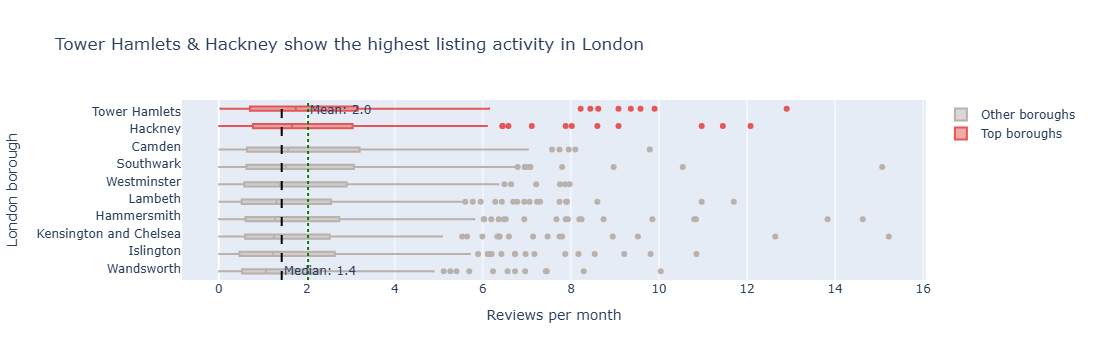

In [16]:
# Task 2 — Remove inactive or new listings
activity_df = df[df['reviews_per_month'] > 0].copy()

# Sort boroughs by median reviews per month
borough_order = (
    activity_df.groupby('neighbourhood')['reviews_per_month']
    .median()
    .sort_values(ascending=False)
    .index
)

# Top 2 most active boroughs
top2 = borough_order[:2]

# Highlight top boroughs
activity_df['highlight'] = np.where(
    activity_df['neighbourhood'].isin(top2),
    'Top boroughs',
    'Other boroughs'
)

# Box plot
fig = px.box(
    activity_df,
    x='reviews_per_month',
    y='neighbourhood',
    color='highlight',
    orientation='h',
    points='outliers',
    category_orders={
        'neighbourhood': borough_order
    },
    color_discrete_map={
        'Top boroughs': '#E45756',
        'Other boroughs': '#BAB0AC'
    },
    title=f"{' & '.join(top2)} show the highest listing activity in London"
)

# Mean and median reference lines
mean_reviews = activity_df['reviews_per_month'].mean()
median_reviews = activity_df['reviews_per_month'].median()

fig.add_vline(
    x=mean_reviews,
    line_dash='dot',
    line_color='green',
    annotation_text=f'Mean: {mean_reviews:.1f}',
    annotation_position='top right'
)

fig.add_vline(
    x=median_reviews,
    line_dash='dash',
    line_color='black',
    annotation_text=f'Median: {median_reviews:.1f}',
    annotation_position='bottom right'
)

# Layout updates
fig.update_layout(
    xaxis_title='Reviews per month',
    yaxis_title='London borough',
    legend_title=''
)

fig.show()